# Decision Tree Classification – Meat Category Prediction

**Target Variable:** `meat_type` (classes 1–5)

**Workflow:**
1. Load & explore the training dataset (`meat_price_dataset.csv`)
2. Preprocess features & split into train/test sets
3. Train a Decision Tree Classifier
4. Evaluate on the internal test split
5. Load the external stress-test dataset (`meat_price_100_stress_test.csv`)
6. Evaluate the model on the stress-test data (with missing-value handling)


## Step 1 – Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

print("All imports successful.")


All imports successful.


## Step 2 – Load the Training Dataset

We load `meat_price_dataset.csv` and take a first look at shape, types, and missing values.


In [2]:
df = pd.read_csv("meat_price_dataset.csv")

print(f"Shape: {df.shape}")
print(f"Missing values:{df.isnull().sum()}")
df.head()


Shape: (1200, 9)
Missing values:meat_type            0
fat_content_pct      0
protein_pct          0
marbling_score       0
animal_age_months    0
storage_days         0
organic              0
cut_quality          0
price_eur_per_kg     0
dtype: int64


,meat_type,fat_content_pct,protein_pct,marbling_score,animal_age_months,storage_days,organic,cut_quality,price_eur_per_kg
0,1,17.8,21.7,7,49,14,1,3,17.27
1,4,27.1,21.9,9,22,4,0,4,29.69
2,4,31.8,16.5,7,20,1,0,2,24.41
3,3,25.8,22.6,6,11,16,0,2,15.08
4,3,33.8,22.4,5,2,17,0,4,20.57


In [3]:
# --- Feature Engineering ---
df["price_per_protein"] = df["price_eur_per_kg"] / df["protein_pct"]
df["fat_to_protein_ratio"] = df["fat_content_pct"] / df["protein_pct"]
df["price_x_marbling"] = df["price_eur_per_kg"] * df["marbling_score"]

print(f"New columns added: {df.shape[1]} total columns")
df.head()

New columns added: 12 total columns


,meat_type,fat_content_pct,protein_pct,marbling_score,animal_age_months,storage_days,organic,cut_quality,price_eur_per_kg,price_per_protein,fat_to_protein_ratio,price_x_marbling
0,1,17.8,21.7,7,49,14,1,3,17.27,0.795853,0.820276,120.89
1,4,27.1,21.9,9,22,4,0,4,29.69,1.355708,1.237443,267.21
2,4,31.8,16.5,7,20,1,0,2,24.41,1.479394,1.927273,170.87
3,3,25.8,22.6,6,11,16,0,2,15.08,0.667257,1.141593,90.48
4,3,33.8,22.4,5,2,17,0,4,20.57,0.918304,1.508929,102.85


## Step 3 – Exploratory Data Analysis (EDA)

A quick look at the class distribution and feature correlations.


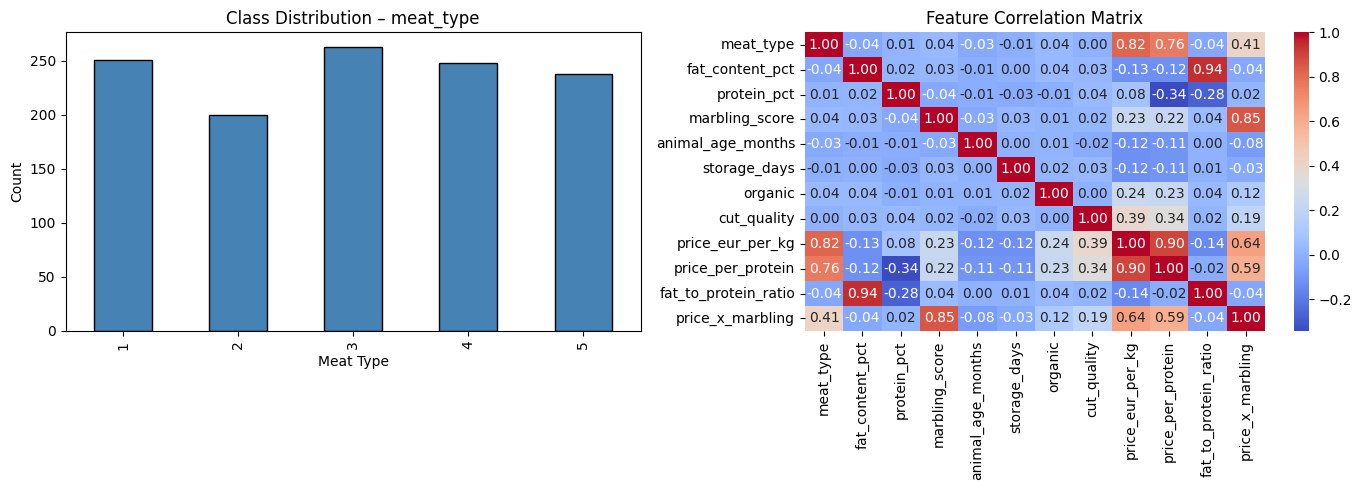

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
df["meat_type"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="black"
)
axes[0].set_title("Class Distribution – meat_type")
axes[0].set_xlabel("Meat Type")
axes[0].set_ylabel("Count")

# Correlation heatmap
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()


### Correlation Check – Which features predict meat_type?

A quick sanity check to confirm we have useful signal.


In [5]:
print("Correlations with meat_type:")
print(df.corr()["meat_type"].drop("meat_type").sort_values(ascending=False).round(3))


Correlations with meat_type:
price_eur_per_kg        0.820
price_per_protein       0.760
price_x_marbling        0.411
marbling_score          0.038
organic                 0.037
protein_pct             0.011
cut_quality             0.003
storage_days           -0.010
animal_age_months      -0.032
fat_content_pct        -0.039
fat_to_protein_ratio   -0.041
Name: meat_type, dtype: float64


## Step 4 – Define Features and Target

We use all columns except `meat_type` (our target) as features.
`price_eur_per_kg` is included because it has a strong 0.82 correlation
with meat type — price naturally differs across meat categories.


In [6]:
target_col = "meat_type"

feature_cols = [c for c in df.columns if c != target_col]
print("Features:", feature_cols)

X = df[feature_cols]
y = df[target_col]

print(f"X shape: {X.shape}  |  y shape: {y.shape}")


Features: ['fat_content_pct', 'protein_pct', 'marbling_score', 'animal_age_months', 'storage_days', 'organic', 'cut_quality', 'price_eur_per_kg', 'price_per_protein', 'fat_to_protein_ratio', 'price_x_marbling']
X shape: (1200, 11)  |  y shape: (1200,)


## Step 5 – Train / Test Split

We hold out 20 % of the data for testing and use `stratify=y` so every
meat type keeps roughly the same proportion in both sets.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# stratify keep the same class proportions in train and test 

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test  set: {X_test.shape[0]} rows")


Train set: 960 rows
Test  set: 240 rows


## Step 6 – Train the Decision Tree

We start with `max_depth=5` to balance complexity and generalization.


In [8]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
)

dt_model.fit(X_train, y_train)

print("Model trained.")
print(f"Tree depth : {dt_model.get_depth()}")
print(f"Leaf nodes : {dt_model.get_n_leaves()}")


Model trained.
Tree depth : 5
Leaf nodes : 30


## Step 7 – Evaluate on the Internal Test Set

We predict on the 20 % hold-out and look at accuracy, classification report,
and confusion matrix.


In [9]:
y_pred = dt_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.5292
              precision    recall  f1-score   support

           1       0.65      0.64      0.65        50
           2       0.44      0.35      0.39        40
           3       0.41      0.60      0.49        52
           4       0.36      0.18      0.24        50
           5       0.69      0.85      0.77        48

    accuracy                           0.53       240
   macro avg       0.51      0.52      0.51       240
weighted avg       0.51      0.53      0.51       240



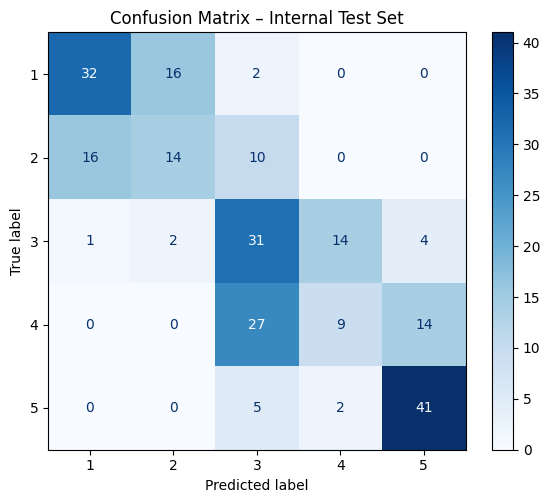

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix – Internal Test Set")
plt.tight_layout()
plt.show()


## Step 8 – Visualise the Decision Tree

A visual representation of the tree structure (limited to depth 3 for readability).


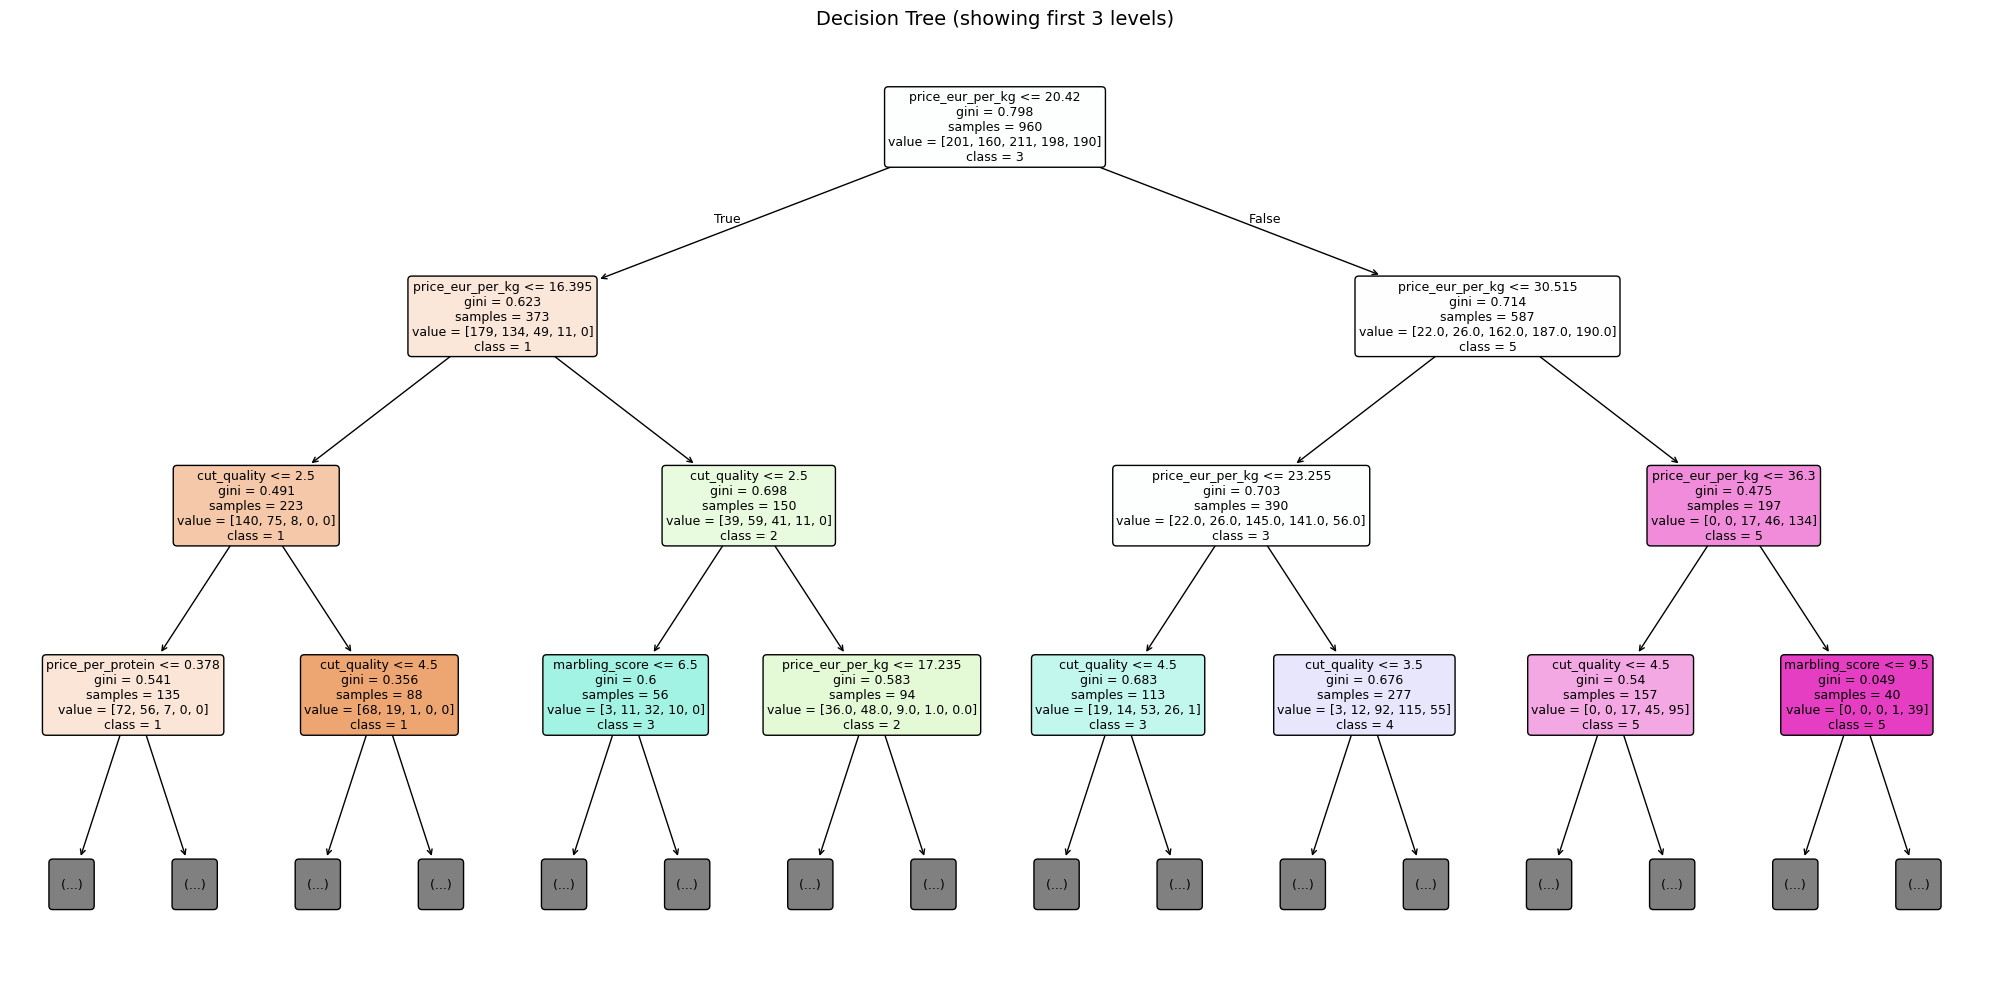

In [11]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree (showing first 3 levels)", fontsize=14)
plt.tight_layout()
plt.show()


## Step 9 – Feature Importance

Which features does the tree rely on most?


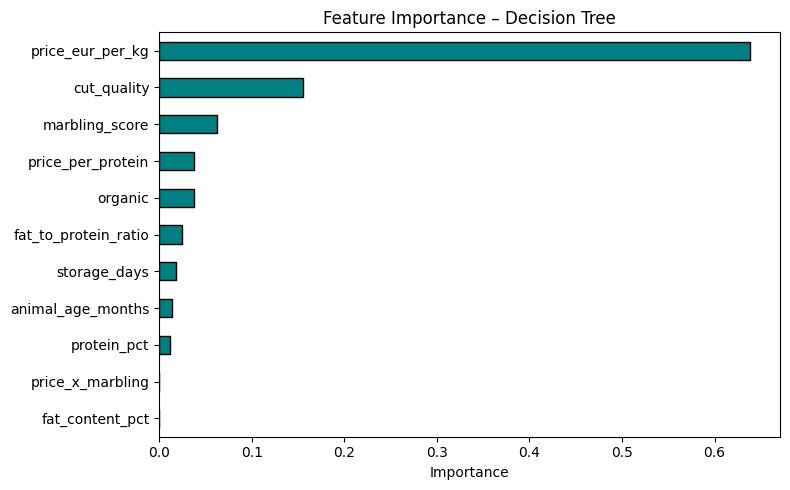

In [12]:
importances = pd.Series(dt_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="teal", edgecolor="black")
ax.set_title("Feature Importance – Decision Tree")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## Step 10 – Load the Stress-Test Dataset

`meat_price_100_stress_test.csv` contains 100 rows with intentional edge cases
and **missing values**. We need to handle NaNs before predicting.


In [13]:
df_stress = pd.read_csv("meat_price_100_stress_test.csv")

# --- Feature Engineering (same as training) ---
df_stress["price_per_protein"] = df_stress["price_eur_per_kg"] / df_stress["protein_pct"]
df_stress["fat_to_protein_ratio"] = df_stress["fat_content_pct"] / df_stress["protein_pct"]
df_stress["price_x_marbling"] = df_stress["price_eur_per_kg"] * df_stress["marbling_score"]

print(f"Shape: {df_stress.shape}")
print(f"Missing values:{df_stress.isnull().sum()}")
df_stress.head()


Shape: (100, 12)
Missing values:meat_type                9
fat_content_pct         14
protein_pct             10
marbling_score          11
animal_age_months        8
storage_days             9
organic                  9
cut_quality              7
price_eur_per_kg         9
price_per_protein       18
fat_to_protein_ratio    22
price_x_marbling        18
dtype: int64


,meat_type,fat_content_pct,protein_pct,marbling_score,animal_age_months,storage_days,organic,cut_quality,price_eur_per_kg,price_per_protein,fat_to_protein_ratio,price_x_marbling
0,4.0,32.2,21.8,3.0,8.0,12.0,0.0,5.0,32.28,1.480734,1.477064,96.84
1,5.0,30.1,22.4,7.0,69.0,14.0,0.0,4.0,38.22,1.706250,1.343750,267.54
2,3.0,16.8,NaN,2.0,59.0,15.0,NaN,2.0,27.56,NaN,NaN,55.12
3,5.0,5.1,20.4,2.0,30.0,10.0,0.0,2.0,45.09,2.210294,0.250000,90.18
4,5.0,14.2,NaN,NaN,37.0,4.0,1.0,3.0,NaN,NaN,NaN,NaN


## Step 11 – Preprocess the Stress-Test Data

We fill missing values with the **median from the training set** so no
information from the stress-test leaks into the imputation.


In [14]:
# Separate features & target (target might also have NaNs)
X_stress = df_stress[feature_cols].copy()
y_stress = df_stress[target_col].copy()

# Impute missing feature values with training-set medians
train_medians = X_train.median()
X_stress_filled = X_stress.fillna(train_medians)

print("Missing values after imputation:")
print(X_stress_filled.isnull().sum())

# Drop rows where the target itself is NaN (can't evaluate without a label)
valid_mask = y_stress.notna()
X_stress_valid = X_stress_filled[valid_mask]
y_stress_valid = y_stress[valid_mask].astype(int)

print(f"Usable stress-test rows: {X_stress_valid.shape[0]} / {len(df_stress)}")


Missing values after imputation:
fat_content_pct         0
protein_pct             0
marbling_score          0
animal_age_months       0
storage_days            0
organic                 0
cut_quality             0
price_eur_per_kg        0
price_per_protein       0
fat_to_protein_ratio    0
price_x_marbling        0
dtype: int64
Usable stress-test rows: 91 / 100


## Step 12 – Evaluate on the Stress-Test Data

Now we run the same model against the cleaned stress-test set.


In [15]:
y_stress_pred = dt_model.predict(X_stress_valid)

acc_stress = accuracy_score(y_stress_valid, y_stress_pred)
print(f"Stress-Test Accuracy: {acc_stress:.4f}")
print(classification_report(y_stress_valid, y_stress_pred, zero_division=0))


Stress-Test Accuracy: 0.2637
              precision    recall  f1-score   support

           1       0.67      0.22      0.33        18
           2       0.00      0.00      0.00        17
           3       0.16      0.42      0.23        12
           4       0.11      0.04      0.06        25
           5       0.33      0.74      0.45        19

    accuracy                           0.26        91
   macro avg       0.25      0.28      0.21        91
weighted avg       0.25      0.26      0.21        91



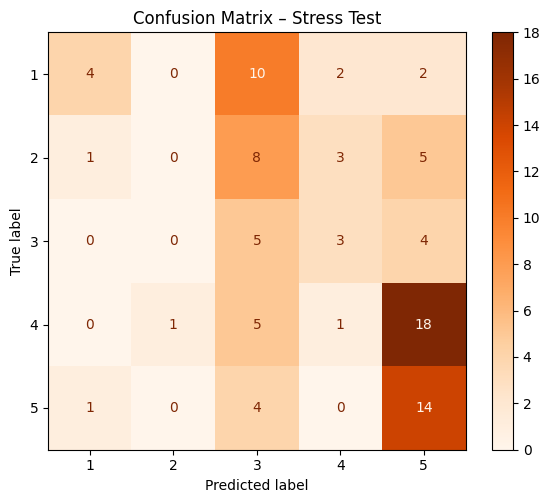

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_stress_valid, y_stress_pred, ax=ax, cmap="Oranges"
)
ax.set_title("Confusion Matrix – Stress Test")
plt.tight_layout()
plt.show()


## Step 13 – Side-by-Side Comparison

A quick summary comparing internal test vs. stress-test performance.


In [17]:
comparison = pd.DataFrame({
    "Dataset": ["Internal Test (20%)", "Stress Test (100 rows)"],
    "Rows":   [len(y_test), len(y_stress_valid)],
    "Accuracy": [f"{acc:.4f}", f"{acc_stress:.4f}"],
})

print(comparison.to_string(index=False))

print("--- Done! ---")


               Dataset  Rows Accuracy
   Internal Test (20%)   240   0.5292
Stress Test (100 rows)    91   0.2637
--- Done! ---


In [18]:
# run it and test it  The code is from Claude 